# [실습4] 머신러닝을 활용한 양극소재 기반 배터리 특성 예측(정답)
---

## 실습 목표

- 머신러닝 분류 모델들의 원리를 이해하고 코드를 작성합니다.
- 주성분 분석을 통해 저차원 공간에서 피처가 분리되는 것을 확인합니다.
- 분류 모델들의 성능을 비교해봅니다. 각각 토이 데이터셋과 실습 데이터셋에서 검증합니다.

---

## 실습 목차

1. **토이 데이터셋 전처리** 

2. **주성분 분석(PCA)** 

3. **로지스틱 회귀 모델**

4. **결정 트리** 

5. **K-최근접 이웃(KNN)** 

6. **랜덤 포레스트(Random Forest)** 

7. **XGBoost** 

8. **실습 데이터 불러오기 및 분류 모델 적용** 
---

## 실습 개요

이번 실습에서는 머신러닝 분류 모델들을 구현하고 실습 데이터에 어떻게 적용될 수 있는지 확인합니다.

---

## 1. 토이 데이터셋 전처리
---
우선 타이타닉 토이 데이터셋을 이용해 머신러닝 알고리즘들을 적용해보겠습니다.

In [832]:
## 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

---
### 1.1 토이 데이터셋 불러오기
타이타닉 데이터셋을 불러옵니다.

In [833]:
df = pd.read_csv('./data/titanic_processed.csv') # df: dataframe의 줄임말
df.drop(columns = df.columns[0], axis = 1, inplace= True) # 데이터 순서를 표현하는 첫 열을 제거합니다.
display(df)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,title,gender,grade
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",Miss,0,0
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",Rare_m,1,4
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",Miss,0,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",Mr,1,1
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",Mrs,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1040,3,0,"Youseff, Mr. Gerious",male,45.5000,0,0,2628,7.2250,NaN,C,NaN,312.0,NaN,Mr,1,1
1041,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN,Miss,0,0
1042,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,Mr,1,1
1043,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,Mr,1,1


해당 승객의 생존 여부를 정답 데이터로 지정하겠습니다. 나머지 데이터를 입력 데이터로 지정합니다.

In [834]:
from sklearn.model_selection import train_test_split

X = df[['pclass', 'age', 'sibsp', 'parch', 'fare', 'gender', 'grade']].astype('float')

y = df['survived']

display(X)
display(y)

,pclass,age,sibsp,parch,fare,gender,grade
0,1.0,29.0000,0.0,0.0,211.3375,0.0,0.0
1,1.0,0.9167,1.0,2.0,151.5500,1.0,4.0
2,1.0,2.0000,1.0,2.0,151.5500,0.0,0.0
3,1.0,30.0000,1.0,2.0,151.5500,1.0,1.0
4,1.0,25.0000,1.0,2.0,151.5500,0.0,2.0
...,...,...,...,...,...,...,...
1040,3.0,45.5000,0.0,0.0,7.2250,1.0,1.0
1041,3.0,14.5000,1.0,0.0,14.4542,0.0,0.0
1042,3.0,26.5000,0.0,0.0,7.2250,1.0,1.0
1043,3.0,27.0000,0.0,0.0,7.2250,1.0,1.0


0       1
1       1
2       0
3       0
4       0
       ..
1040    0
1041    0
1042    0
1043    0
1044    0
Name: survived, Length: 1045, dtype: int64

---
### 1.2 정규화 & 표준화
토이 데이터셋에 정규화와 표준화를 진행합니다. 

In [835]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
std_scaler.fit(X)
scaled_X = std_scaler.transform(X)
X = pd.DataFrame(scaled_X, columns=X.columns, index=list(X.index.values))
display(X)

,pclass,age,sibsp,parch,fare,gender,grade
0,-1.434601,-0.059228,-0.551897,-0.501462,3.135243,-1.301268,-1.192463
1,-1.434601,-2.011855,0.544553,1.880484,2.061972,0.768481,2.840299
2,-1.434601,-1.936534,0.544553,1.880484,2.061972,-1.301268,-1.192463
3,-1.434601,0.010302,0.544553,1.880484,2.061972,0.768481,-0.184272
4,-1.434601,-0.337347,0.544553,1.880484,2.061972,-1.301268,0.823918
...,...,...,...,...,...,...,...
1040,0.943128,1.088014,-0.551897,-0.501462,-0.528869,0.768481,-0.184272
1041,0.943128,-1.067411,0.544553,-0.501462,-0.399094,-1.301268,-1.192463
1042,0.943128,-0.233052,-0.551897,-0.501462,-0.528869,0.768481,-0.184272
1043,0.943128,-0.198288,-0.551897,-0.501462,-0.528869,0.768481,-0.184272


---
### 1.3 학습 & 테스트 데이터 구분

In [836]:

random_seed = 42
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.3, random_state = random_seed)


---

## 2. 주성분 분석(PCA)
토이 데이터셋에 PCA 알고리즘을 적용해봅니다. 

PCA는 Principal Component Analysis로, 피처의 차원을 축소하여 원하는 개수의 주성분으로 표현하는 기법입니다. 

이는 고차원의 데이터를 저차원의 데이터로 변환하는 차원 축소 방법 중 하나입니다.

---
### 2.1 2차원 PCA 
데이터를 2차원으로 축소합니다. 즉, 주성분이 2개로 이뤄져있습니다.

In [837]:
from sklearn.decomposition import PCA

def get_pca_data(ss_data, n_components = 2):
    pca = PCA(n_components = n_components)
    pca.fit(ss_data)
    
    return pca.transform(ss_data), pca

PCA를 적용하여 차원을 축소합니다.

In [838]:
pca_data, pca = get_pca_data(X_train, n_components=2)

### 2.2 2차원 PCA 결과 시각화
축소된 차원을 2차원 그래프로 시각화합니다.

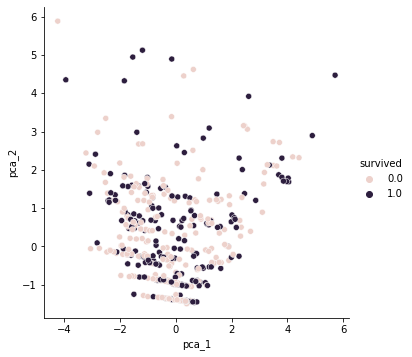

In [839]:
import seaborn as sns

pca_columns = ['pca_1', 'pca_2']
pca_pd = pd.DataFrame(pca_data, columns=pca_columns)
pca_pd['survived'] = Y_train

sns.pairplot(pca_pd, hue='survived', height=5,
             x_vars=['pca_1'], y_vars=['pca_2'])

plt.show()

2차원 그래프로는 생존 여부에 따라 피처가 잘 구분되지 않는 것을 확인할 수 있습니다.

---
### 2.3 3차원 PCA
데이터를 3차원으로 축소합니다. 즉, 주성분이 3개로 이뤄져있습니다.

In [840]:
pca_data, pca = get_pca_data(X_train, n_components=3)

시각화를 위해 pandas 데이터 형태로 변환하는 함수를 선언합니다.

In [841]:
def get_pd_from_pca(pca_data, col_num):
    cols = ['pca_'+str(n) for n in range(col_num)]
    return pd.DataFrame(pca_data, columns = cols)

In [842]:
pca_pd = get_pd_from_pca(pca_data, 3)

pca_pd['survived'] = Y_train.values
pca_pd.head()

,pca_0,pca_1,pca_2,survived
0,-0.638039,-0.465588,-1.725913,1
1,-0.551518,-0.870062,0.431762,0
2,-1.449227,-0.673031,0.796963,0
3,-0.473322,-0.881938,0.398697,0
4,0.380616,-1.423265,0.197515,0


---
### 2.4 3차원 PCA 결과 시각화
축소된 차원을 3차원 그래프로 시각화합니다.

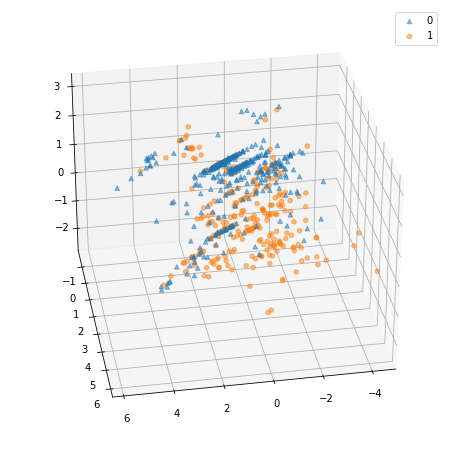

In [843]:
from mpl_toolkits.mplot3d import Axes3D

markers = ['^', 'o']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i, marker in enumerate(markers):
    x_axis_data = pca_pd[pca_pd['survived'] == i]['pca_0']
    y_axis_data = pca_pd[pca_pd['survived'] == i]['pca_1']
    z_axis_data = pca_pd[pca_pd['survived'] == i]['pca_2']

    ax.scatter(x_axis_data, y_axis_data, z_axis_data,
               s=20, alpha=0.5, marker=marker, label=str(i))
    
ax.view_init(30, 80)
plt.legend()
plt.show()

2차원 PCA 결과보다 데이터가 축소 차원 공간에서 더 잘 구분되는 것을 확인할 수 있습니다.

PCA 결과를 통해 간단한 머신러닝 알고리즘의 예측 성능을 간접적으로 유추해볼 수 있습니다.

2차원 혹은 3차원 PCA 결과로 축소 차원 공간에서 데이터가 완벽하게 분류된다면, 매우 간단한 알고리즘으로도 높은 정확도로 분류를 할 수 있습니다.

이와 반대 상황이라면, 보다 복잡하고 비선형성이 강한 알고리즘을 선택해야 합니다.

## 3. 로지스틱 회귀 모델
이전 실습에서 적용했었던 로지스틱 회귀 모델을 토이 데이터셋에 동일하게 적용해보겠습니다.

추후 다른 알고리즘들과 성능을 비교합니다.

---
### 3.1 로지스틱 회귀 모델 학습

In [844]:
from sklearn.linear_model import LogisticRegression #logistic regression
model = LogisticRegression()
model.fit(X_train, Y_train)

LogisticRegression()

---
### 3.2 모델 성능 확인
생존 여부의 예측 성능을 확인합니다.

In [845]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluation(prediction, Y_test, model_name="모델 이름"):
    print(model_name, "의 정답률은 %.2f%% 입니다." % (accuracy_score(prediction, Y_test) * 100))
    print(model_name, "의 정밀도는 %.2f 입니다." % precision_score(Y_test, prediction))
    print(model_name, "의 재현율은 %.2f 입니다." % recall_score(Y_test, prediction))
    print(model_name, "의 F1 점수는 %.2f 입니다." % f1_score(Y_test, prediction))
    print(model_name, "의 ROC-AUC 점수는 %.2f 입니다." % roc_auc_score(Y_test, prediction))

In [846]:
LR_prediction = model.predict(X_test)
evaluation(LR_prediction, Y_test, model_name="로지스틱 회귀 모델")

로지스틱 회귀 모델 의 정답률은 75.16% 입니다.
로지스틱 회귀 모델 의 정밀도는 0.74 입니다.
로지스틱 회귀 모델 의 재현율은 0.68 입니다.
로지스틱 회귀 모델 의 F1 점수는 0.71 입니다.
로지스틱 회귀 모델 의 ROC-AUC 점수는 0.74 입니다.


타이타닉 영화의 두 주인공이 생존할 수 있었을지 예측해봅니다.

Decaprio와 Winslet의 영화 설정 상 데이터를 구성해주고, 이를 함수로 정의합니다.

모든 알고리즘에서 생존 여부를 출력해보겠습니다.

In [847]:
def check_survive(model):
    # 'pclass', 'age', 'sibsp', 'parch', 'fare', 'gender', 'grade'
    decaprio = np.array([[3, 18, 0, 0, 5, 1, 1]])
    decaprio = pd.DataFrame(decaprio, columns=X.columns)
    decaprio = std_scaler.transform(decaprio)
    decaprio = pd.DataFrame(decaprio, columns=X.columns)
    print('Decaprio : ', model.predict(decaprio)[0])

    winslet = np.array([[1, 16, 1, 1, 100, 0, 3]])
    winslet = pd.DataFrame(winslet, columns=X.columns)
    winslet = std_scaler.transform(winslet)
    winslet = pd.DataFrame(winslet, columns=X.columns)
    print('Winslet : ', model.predict(winslet)[0])


In [848]:
check_survive(model)

Decaprio :  0
Winslet :  1


Decaprio는 생존하지 못하고, Winslet은 생존을 하는 것으로 예측되었습니다.

---
## 4. 결정 트리
---
### 4.1 결정 트리 모델 학습

In [849]:
from sklearn.tree import DecisionTreeClassifier #Decision Tree

model = DecisionTreeClassifier()
model.fit(X_train, Y_train)


DecisionTreeClassifier()

---
### 4.2 모델 성능 확인
생존 여부의 예측 성능을 확인합니다.

In [850]:
DT_prediction = model.predict(X_test)
evaluation(DT_prediction, Y_test, model_name="결정 트리 모델")

결정 트리 모델 의 정답률은 74.20% 입니다.
결정 트리 모델 의 정밀도는 0.76 입니다.
결정 트리 모델 의 재현율은 0.61 입니다.
결정 트리 모델 의 F1 점수는 0.68 입니다.
결정 트리 모델 의 ROC-AUC 점수는 0.73 입니다.


In [851]:
check_survive(model)

Decaprio :  0
Winslet :  1


---
## 5. K-최근접 이웃(KNN)
---
### 5.1 KNN 모델 학습

In [852]:
from sklearn.neighbors import KNeighborsClassifier #KNN

model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=9)

---
### 5.2 모델 성능 확인
생존 여부의 예측 성능을 확인합니다.

In [853]:
KNN_prediction = model.predict(X_test)
evaluation(KNN_prediction, Y_test, model_name="KNN")

KNN 의 정답률은 77.39% 입니다.
KNN 의 정밀도는 0.78 입니다.
KNN 의 재현율은 0.68 입니다.
KNN 의 F1 점수는 0.73 입니다.
KNN 의 ROC-AUC 점수는 0.76 입니다.


In [854]:
check_survive(model)

Decaprio :  0
Winslet :  1


---
### 5.3 이웃 파라미터에 따른 성능 분석
KNN은 이웃 파라미터의 크기에 따라 성능이 크게 좌우되는 알고리즘입니다.

이웃 파라미터를 조정하면서 성능을 확인해보겠습니다.

In [855]:
k_list = np.arange(1,15)
acc_list = []
for i in k_list:
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train, Y_train)
    prediction = model.predict(X_test)
    acc_list.append(accuracy_score(prediction, Y_test))


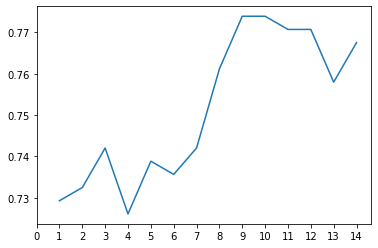

가장 높은 정답률을 보이는 이웃 파라미터는  9 입니다.


In [856]:
acc_list = np.array(acc_list)
x = np.arange(0,15)
plt.plot(k_list, acc_list)
plt.xticks(x)
plt.show()
print('가장 높은 정답률을 보이는 이웃 파라미터는 ', np.argmax(acc_list)+1, '입니다.')

---
## 6. 랜덤 포레스트(Random Forest)
---
### 6.1 랜덤 포레스트 모델 학습

In [857]:
from sklearn.ensemble import RandomForestClassifier #Random Forest

model = RandomForestClassifier()
model.fit(X_train, Y_train)

RandomForestClassifier()

---
### 6.2 모델 성능 확인
생존 여부의 예측 성능을 확인합니다.

In [858]:
RF_prediction = model.predict(X_test)
evaluation(RF_prediction, Y_test, model_name="랜덤 포레스트 모델")

랜덤 포레스트 모델 의 정답률은 75.16% 입니다.
랜덤 포레스트 모델 의 정밀도는 0.75 입니다.
랜덤 포레스트 모델 의 재현율은 0.65 입니다.
랜덤 포레스트 모델 의 F1 점수는 0.70 입니다.
랜덤 포레스트 모델 의 ROC-AUC 점수는 0.74 입니다.


In [859]:
check_survive(model)

Decaprio :  0
Winslet :  1


---
## 7. XGBoost
---
### 7.1 XGBoost 모델 학습

In [860]:
import xgboost as XGBRegressor
model = XGBRegressor.XGBClassifier(n_estimators=900,learning_rate=0.1)
model.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=900, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

---
### 7.2 모델 성능 확인
생존 여부의 예측 성능을 확인합니다.

In [861]:
XGB_prediction = model.predict(X_test)
evaluation(XGB_prediction, Y_test, model_name="XGBoost 모델")

XGBoost 모델 의 정답률은 75.16% 입니다.
XGBoost 모델 의 정밀도는 0.76 입니다.
XGBoost 모델 의 재현율은 0.65 입니다.
XGBoost 모델 의 F1 점수는 0.70 입니다.
XGBoost 모델 의 ROC-AUC 점수는 0.74 입니다.


In [862]:
check_survive(model)

Decaprio :  0
Winslet :  1


모든 모델의 성능을 바 그래프로 시각화하여 비교해보겠습니다.

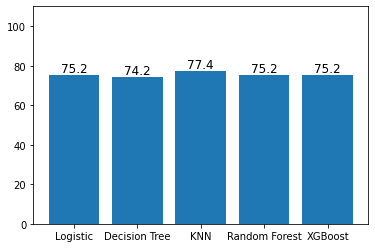

In [863]:
model_list = ['Logistic', 'Decision Tree', 'KNN', 'Random Forest', 'XGBoost']
result_list = [accuracy_score(LR_prediction, Y_test)*100,
               accuracy_score(DT_prediction, Y_test)*100,
               accuracy_score(KNN_prediction, Y_test)*100,
               accuracy_score(RF_prediction, Y_test)*100,
               accuracy_score(XGB_prediction, Y_test)*100
              ] 

bar = plt.bar(model_list, result_list)
for rect in bar:
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height, '%.1f' % height, ha='center', va='bottom', size = 12)
plt.ylim(0, 110)
plt.show()      

알고리즘 별 성능의 차이가 크지 않은 것으로 확인됩니다.

---
## 8. 실습 데이터 불러오기 및 분류 모델 적용
머신러닝 분류 모델들을 실습 데이터에 적용해보겠습니다.

---
### 8.1 실습 데이터 불러오기
이전 실습에서 모든 전처리가 끝난 실습데이터를 불러오겠습니다.

In [864]:
df = pd.read_csv('./data/processed.csv') # df: dataframe의 줄임말
df.drop(columns = df.columns[0], axis = 1, inplace= True) # 데이터 순서를 표현하는 첫 열을 제거합니다.
display(df)

,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Has Bandstructure,Crystal System
0,-0.9460,0.96830,1.1120,-1.5800,0.74170,2.61300,-2.0500,0.03653
1,-0.9460,-1.51900,-0.8633,1.1600,-0.55500,-0.63300,-2.0500,0.03653
2,-0.8640,0.07587,-0.4023,0.9644,-0.55500,1.21500,0.4863,1.16200
3,-0.7820,0.15210,0.9810,-1.0090,0.74170,1.06500,0.4863,-1.08900
4,-0.9460,-0.09820,0.8490,-0.2323,0.09344,-1.55700,0.4863,0.03653
...,...,...,...,...,...,...,...,...
324,-0.1285,0.51100,-1.4560,0.5635,-0.29570,0.49440,0.4863,1.16200
325,1.5060,0.51660,-1.4230,0.6226,-0.29570,0.68360,0.4863,1.16200
326,-0.9460,0.50600,1.3430,-1.0150,-0.72800,0.13280,0.4863,0.03653
327,-0.8640,-0.26680,0.6846,0.5664,-0.55500,-0.11304,0.4863,1.16200


---
### 8.2 학습 & 테스트 데이터 구분
7:3 의 비율로 학습 데이터와 테스트 데이터를 구분합니다.

이때 Crystal System 데이터를 정답 데이터로 분리합니다.

In [865]:
target_col = 'Crystal System'

y = df[target_col]
y = y.astype('category').cat.codes
X = df.drop(target_col, axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(230, 7)
(99, 7)
(230,)
(99,)


---
### 8.3 2차원 PCA 적용

In [866]:
pca_data, pca = get_pca_data(X_train, n_components=2)

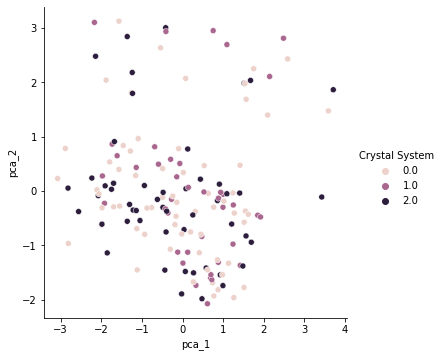

In [867]:
import seaborn as sns

pca_columns = ['pca_1', 'pca_2']
pca_pd = pd.DataFrame(pca_data, columns=pca_columns)
pca_pd['Crystal System'] = Y_train

sns.pairplot(pca_pd, hue='Crystal System', height=5,
             x_vars=['pca_1'], y_vars=['pca_2'])

plt.show()

---
### 8.4 3차원 PCA 적용

In [868]:
pca_data, pca = get_pca_data(X_train, n_components=3)

In [869]:
pca_pd = get_pd_from_pca(pca_data, 3)

pca_pd['Crystal System'] = Y_train.values
pca_pd.head()

,pca_0,pca_1,pca_2,Crystal System
0,0.995316,-0.297258,0.629772,0
1,0.476017,-0.834742,-1.048907,1
2,-1.216308,-0.348555,2.676770,2
3,0.785045,-1.250869,-1.016309,2
4,-0.358576,-0.402842,-0.879473,1


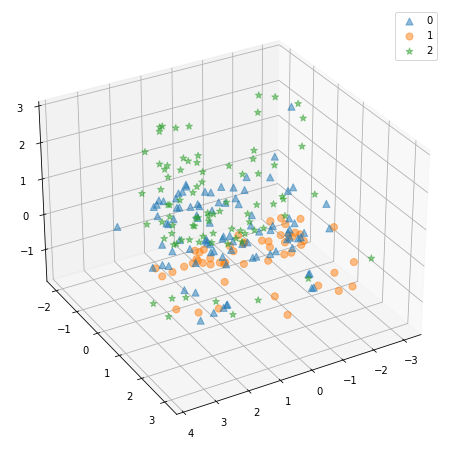

In [870]:
from mpl_toolkits.mplot3d import Axes3D

markers = ['^', 'o', '*']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i, marker in enumerate(markers):
    x_axis_data = pca_pd[pca_pd['Crystal System'] == i]['pca_0']
    y_axis_data = pca_pd[pca_pd['Crystal System'] == i]['pca_1']
    z_axis_data = pca_pd[pca_pd['Crystal System'] == i]['pca_2']

    ax.scatter(x_axis_data, y_axis_data, z_axis_data,
               s=50, alpha=0.5, marker=marker, label=str(i))
    
ax.view_init(30, 60)
plt.legend()
plt.show()

---
### 8.5 로지스틱 회귀 모델 적용

In [871]:
# 다중 클래스 분류를 위한 로지스틱 회귀 모델
model = LogisticRegression(multi_class='multinomial', solver='lbfgs')
model.fit(X_train, Y_train)


LogisticRegression(multi_class='multinomial')

실습 데이터는 정답 데이터의 클래스가 3개입니다. 즉, 다중 분류(Multi-Classs) 문제입니다.

이때, 이진 분류 문제의 평가 지표들을 그대로 적용할 수는 없습니다.

따라서, 성능 지표 함수에 다중 분류 성능을 어떻게 평가할지 지정해줘야 합니다.

본 실습에서는 가장 많이 사용하는 weighted 방법을 사용하겠습니다.

In [872]:
def evaluation(prediction, Y_test, model_name="모델 이름"):
    print(model_name, "의 정답률은 %.2f%% 입니다." % (accuracy_score(prediction, Y_test) * 100))
    print(model_name, "의 정밀도는 %.2f 입니다." % precision_score(Y_test, prediction, average='weighted'))
    print(model_name, "의 재현율은 %.2f 입니다." % recall_score(Y_test, prediction, average='weighted'))
    print(model_name, "의 F1 점수는 %.2f 입니다." % f1_score(Y_test, prediction, average='weighted'))

AUC-ROC의 경우, 다중 분류 문제일 경우 각 클래스 별 예측 확률이 필요합니다.

별도의 함수를 만들어 처리합니다.

In [873]:
def multi_class_auc(prediction_prob, Y_test, model_name="모델 이름"):
    print(model_name, "의 ROC-AUC 점수는 %.2f 입니다." % roc_auc_score(Y_test, prediction_prob, multi_class='ovr'))  

In [874]:
LR_prediction = model.predict(X_test)
LR_prediction_prob = model.predict_proba(X_test)
evaluation(LR_prediction, Y_test, model_name="로지스틱 회귀 모델")
multi_class_auc(LR_prediction_prob, Y_test, model_name="로지스틱 회귀 모델")

로지스틱 회귀 모델 의 정답률은 66.67% 입니다.
로지스틱 회귀 모델 의 정밀도는 0.67 입니다.
로지스틱 회귀 모델 의 재현율은 0.67 입니다.
로지스틱 회귀 모델 의 F1 점수는 0.66 입니다.
로지스틱 회귀 모델 의 ROC-AUC 점수는 0.84 입니다.


---
### 8.6 결정 트리 모델 적용

In [875]:

model = DecisionTreeClassifier()
model.fit(X_train, Y_train)

DecisionTreeClassifier()

In [876]:
DT_prediction = model.predict(X_test)
DT_prediction_prob = model.predict_proba(X_test)
evaluation(DT_prediction, Y_test, model_name="결정 트리 모델")
multi_class_auc(DT_prediction_prob, Y_test, model_name="결정 트리 모델")

결정 트리 모델 의 정답률은 94.95% 입니다.
결정 트리 모델 의 정밀도는 0.95 입니다.
결정 트리 모델 의 재현율은 0.95 입니다.
결정 트리 모델 의 F1 점수는 0.95 입니다.
결정 트리 모델 의 ROC-AUC 점수는 0.97 입니다.


---
### 8.7 KNN 모델 적용

In [877]:
model = KNeighborsClassifier(n_neighbors=15)
model.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=15)

In [878]:
KNN_prediction = model.predict(X_test)
KNN_prediction_prob = model.predict_proba(X_test)
evaluation(KNN_prediction, Y_test, model_name="KNN")
multi_class_auc(KNN_prediction_prob, Y_test, model_name="KNN")

KNN 의 정답률은 65.66% 입니다.
KNN 의 정밀도는 0.66 입니다.
KNN 의 재현율은 0.66 입니다.
KNN 의 F1 점수는 0.65 입니다.
KNN 의 ROC-AUC 점수는 0.81 입니다.


이웃 파라미터를 조정하면서 성능을 확인해보겠습니다.

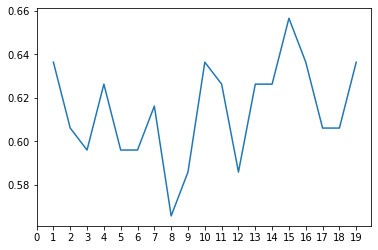

가장 높은 정답률을 보이는 이웃 파라미터는  15 입니다.


In [879]:
k_list = np.arange(1,20)
acc_list = []
for i in k_list:
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train, Y_train)
    prediction = model.predict(X_test)
    acc_list.append(accuracy_score(prediction, Y_test))

acc_list = np.array(acc_list)
x = np.arange(0,20)
plt.plot(k_list, acc_list)
plt.xticks(x)
plt.show()
print('가장 높은 정답률을 보이는 이웃 파라미터는 ', np.argmax(acc_list)+1, '입니다.')

---
### 8.8 랜덤 포레스트 모델 적용

In [880]:
model = RandomForestClassifier()
model.fit(X_train, Y_train)

RandomForestClassifier()

In [881]:
RF_prediction = model.predict(X_test)
RF_prediction_prob = model.predict_proba(X_test)
evaluation(RF_prediction, Y_test, model_name="랜덤 포레스트 모델")
multi_class_auc(RF_prediction_prob, Y_test, model_name="랜덤 포레스트 모델")

랜덤 포레스트 모델 의 정답률은 93.94% 입니다.
랜덤 포레스트 모델 의 정밀도는 0.94 입니다.
랜덤 포레스트 모델 의 재현율은 0.94 입니다.
랜덤 포레스트 모델 의 F1 점수는 0.94 입니다.
랜덤 포레스트 모델 의 ROC-AUC 점수는 0.99 입니다.


---
### 8.9 XGBoost 모델 적용

In [882]:
model = XGBRegressor.XGBClassifier(n_estimators=900,learning_rate=0.1)
model.fit(X_train, Y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=900, n_jobs=None, num_parallel_tree=None,
              objective='multi:softprob', predictor=None, ...)

In [883]:
XGB_prediction = model.predict(X_test)
XGB_prediction_prob = model.predict_proba(X_test)
evaluation(XGB_prediction, Y_test, model_name="XGBoost 모델")
multi_class_auc(XGB_prediction_prob, Y_test, model_name="XGBoost 모델")

XGBoost 모델 의 정답률은 97.98% 입니다.
XGBoost 모델 의 정밀도는 0.98 입니다.
XGBoost 모델 의 재현율은 0.98 입니다.
XGBoost 모델 의 F1 점수는 0.98 입니다.
XGBoost 모델 의 ROC-AUC 점수는 1.00 입니다.


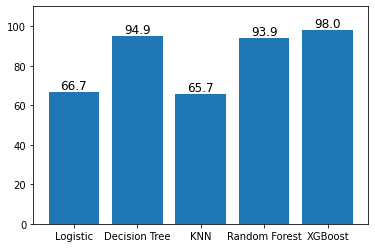

In [884]:
model_list = ['Logistic', 'Decision Tree', 'KNN', 'Random Forest', 'XGBoost']
result_list = [accuracy_score(LR_prediction, Y_test)*100,
               accuracy_score(DT_prediction, Y_test)*100,
               accuracy_score(KNN_prediction, Y_test)*100,
               accuracy_score(RF_prediction, Y_test)*100,
               accuracy_score(XGB_prediction, Y_test)*100
              ] 

bar = plt.bar(model_list, result_list)
for rect in bar:
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height, '%.1f' % height, ha='center', va='bottom', size = 12)
plt.ylim(0, 110)
plt.show()      

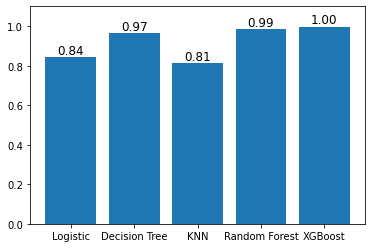

In [885]:
model_list = ['Logistic', 'Decision Tree', 'KNN', 'Random Forest', 'XGBoost']
result_list = [roc_auc_score(Y_test, LR_prediction_prob, multi_class='ovr'),
               roc_auc_score(Y_test, DT_prediction_prob, multi_class='ovr'),
               roc_auc_score(Y_test, KNN_prediction_prob, multi_class='ovr'),
               roc_auc_score(Y_test, RF_prediction_prob, multi_class='ovr'),
               roc_auc_score(Y_test, XGB_prediction_prob, multi_class='ovr')
              ] 

bar = plt.bar(model_list, result_list)
for rect in bar:
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height, '%.2f' % height, ha='center', va='bottom', size = 12)
plt.ylim(0, 1.1)
plt.show()     

알고리즘 별 성능을 확인했을 때, 정답률와 AUC-ROC 두 지표에서 모두 좋은 성능을 보이고 있습니다. 

특히, 결정 트리, 랜덤 포레스트, XGBoost 세 알고리즘이 실습 데이터에 대해서 뛰어난 예측 성능을 보이는 것을 확인할 수 있습니다.